In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from small_world_propensity import SWP

In [8]:
# Read in C. elegans and convert to adjacency matrix
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

# Read in HCP SC and FC for one subject
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')

In [9]:
spis = ['additive_noise', 'barycenter', 'coherence_mag', 'cointegration', 'covariance',
        'directed_info', 'granger', 'integrated_info', 'itakura', 'phase_lag',
        'phase_slope_spectral', 'phase_slope_wavelet', 'power_env_corr', 'transfer_entropy']

spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
subs = os.listdir(spi_dir)

In [6]:
results_fc = {spi: {'SWP': [], 'delta_C': [], 'delta_L': []} for spi in spis}
results_sc = []
for spi in spis:
    for sub in subs:
        fc_path = os.path.join(spi_dir, sub, f'{spi}_symmetrize.npy')
        fc = np.load(fc_path)
        swp, delta_C, delta_L = SWP(fc)
        results_fc[spi]['SWP'].append(swp)
        results_fc[spi]['delta_C'].append(delta_C)
        results_fc[spi]['delta_L'].append(delta_L)

338

In [14]:
results_sc = {'SWP': [],
              'delta_C': [],
              'delta_L': []
             }
for i, sub in tqdm(enumerate(subs)):
    sc_path = os.path.join(sc_dir, f'sub-{sub}_parc-shen268_tract-prob_sc.npy')
    try:
        sc = np.load(sc_path)
    except:
        pass
    swp, delta_C, delta_L = SWP(sc)
    results_sc['SWP'].append(swp)
    results_sc['delta_C'].append(delta_C)
    results_sc['delta_L'].append(delta_L)

213it [02:19,  1.50it/s]

Graph is not fully connected.


338it [03:43,  1.51it/s]


In [15]:
df = pd.DataFrame(results_sc, columns = results_sc.keys())
df.to_csv('sc_results.csv')

In [3]:
df = pd.read_csv('sc_results.csv', index_col='Unnamed: 0')
df.head()

,SWP,delta_C,delta_L
0,0.896315,0.123377,0.079242
1,0.909117,0.091667,0.090091
2,0.877150,0.151932,0.084268
3,0.902155,0.106413,0.088450
4,0.889478,0.131495,0.084493


<Axes: ylabel='SWP'>

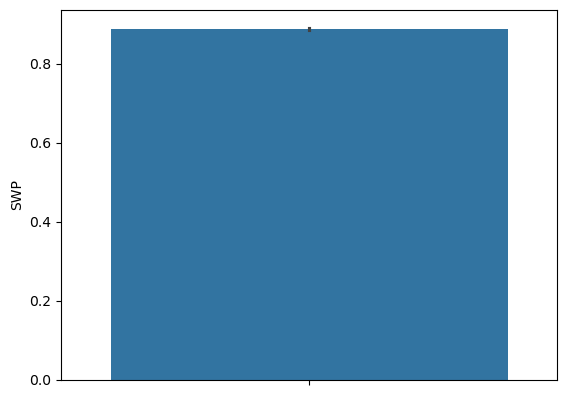

In [4]:
sns.barplot(
    data=df,
    y='SWP',
    errorbar=('ci', 95)
)

<Axes: ylabel='delta_C'>

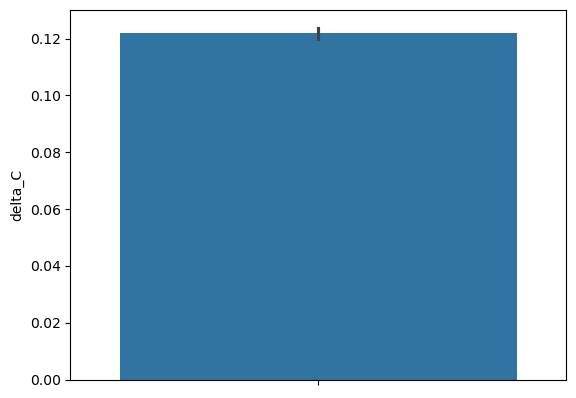

In [5]:
sns.barplot(
    data=df,
    y='delta_C',
    errorbar=('ci', 95)
)

<Axes: ylabel='delta_L'>

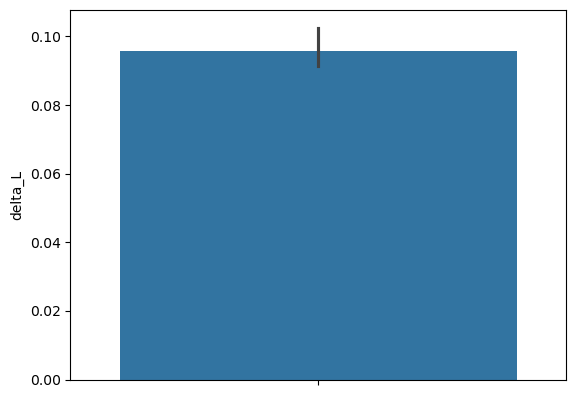

In [6]:
sns.barplot(
    data=df,
    y='delta_L',
    errorbar=('ci', 95)
)

In [14]:
G = nx.Graph(sc)
degrees = list(dict(G.degree()).values())

In [16]:
np.mean(degrees)

np.float64(193.3955223880597)

In [22]:
adj = sc.copy()
N = adj.shape[0]
upper = np.triu(adj, k=1)
E = np.count_nonzero(upper)
r = int(np.round(E/N))
r

97